
# Detector YOLO-pose (jugador + 5 keypoints) — componente adicional

Este notebook **no** forma parte de los criterios de rúbrica de la Actividad 3 (esa es
`actividad_3_clasificacion_visual_cnn.ipynb`). Es trabajo adicional que sienta las bases del modelo final del
proyecto: detectar y trackear en video real, frame por frame, al jugador y sus 5 keypoints (cabeza,
hombro, codo, muñeca, raqueta) — sin depender de recortes ya dados, como sí hace el notebook principal.

Se usa `ultralytics` (YOLOv8n-pose) entrenado **directamente sobre `data/Padel_an_2-6/{train,valid,test}`
tal como están** — no se copian ni reorganizan imágenes a ninguna carpeta nueva.



## Checkpoint 1 — `data.yaml` apuntando directo a `data/Padel_an_2-6`

Sin copiar ni mover nada: se arma un `data.yaml` que apunta directo a
`data/Padel_an_2-6/{train,valid,test}/images` (rutas absolutas), reutilizando `kpt_shape`, `flip_idx`,
`nc` y `names`. Los labels los toma `ultralytics` de la carpeta `labels/` hermana de cada `images/`.

**Nota**: `data/Padel_an_2-6` es la reexportación limpia obtenida en `actividad_3_clasificacion_visual_cnn.ipynb`
(Checkpoint 0.5) — a diferencia del export original del proyecto, no tiene el bug del valor centinela
`2.0`, así que `ultralytics` ya no descarta imágenes por keypoints fuera de rango.


In [1]:

from pathlib import Path
import yaml

def find_repo_root(start=None):
    p = Path(start or Path.cwd())
    for _ in range(5):
        if (p / "data.yaml").exists():
            return p
        p = p.parent
    raise FileNotFoundError("No se encontró data.yaml")

ROOT = find_repo_root()
DATA_DIR = ROOT / "data" / "Padel_an_2-6"

with open(DATA_DIR / "data.yaml") as f:
    orig_cfg = yaml.safe_load(f)
print(orig_cfg)

yolo_cfg = {
    "train": str((DATA_DIR / "train" / "images").resolve()),
    "val": str((DATA_DIR / "valid" / "images").resolve()),
    "test": str((DATA_DIR / "test" / "images").resolve()),
    "kpt_shape": orig_cfg["kpt_shape"],
    "flip_idx": orig_cfg["flip_idx"],
    "nc": orig_cfg["nc"],
    "names": orig_cfg["names"],
}
yaml_path = ROOT / "data" / "processed" / "data_yolo_pose.yaml"
yaml_path.parent.mkdir(parents=True, exist_ok=True)
with open(yaml_path, "w") as f:
    yaml.safe_dump(yolo_cfg, f, sort_keys=False)
print(yaml_path.read_text())


{'flip_idx': [0, 1, 2, 3, 4], 'kpt_shape': [5, 3], 'names': ['Person'], 'nc': 1, 'roboflow': {'license': 'CC BY 4.0', 'project': 'padel_an_2', 'url': 'https://universe.roboflow.com/padel1s-workspace/padel_an_2/dataset/6', 'version': 6, 'workspace': 'padel1s-workspace'}, 'test': '../test/images', 'train': '/Users/psychobolt/Documents/education/universidad_de_la_sabana/maestria_en_inteligencia_artificial/asignaturas/TAIA/unidad_2/padel-impact-position-detection/data/Padel_an_2-6/train/images', 'val': '/Users/psychobolt/Documents/education/universidad_de_la_sabana/maestria_en_inteligencia_artificial/asignaturas/TAIA/unidad_2/padel-impact-position-detection/data/Padel_an_2-6/valid/images'}
train: /Users/psychobolt/Documents/education/universidad_de_la_sabana/maestria_en_inteligencia_artificial/asignaturas/TAIA/unidad_2/padel-impact-position-detection/data/Padel_an_2-6/train/images
val: /Users/psychobolt/Documents/education/universidad_de_la_sabana/maestria_en_inteligencia_artificial/asigna


## Checkpoint 2 — Entrenamiento YOLOv8n-pose

Se usa el modelo pose más liviano de ultralytics (`yolov8n-pose`, backbone preentrenado en COCO-pose;
la cabeza de keypoints se reinicializa porque nuestro `kpt_shape` [5,3] difiere de COCO [17,3]).
Se entrena en GPU cuando está disponible (detectada automáticamente por `ultralytics`).


In [2]:

from ultralytics import YOLO
import torch

SEED = 42
device = 0 if torch.cuda.is_available() else "cpu"
print("Device:", device)

model = YOLO("yolov8n-pose.pt")
results = model.train(
    data=str(yaml_path),
    epochs=60,
    imgsz=384,
    batch=16,
    seed=SEED,
    device=device,
    project=str(ROOT / "runs" / "pose"),
    name="padel_yolo_pose",
    exist_ok=True,
    patience=15,
    verbose=False,
)


Device: cpu
Ultralytics 8.4.162 🚀 Python-3.12.13 torch-2.14.0 CPU (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/psychobolt/Documents/education/universidad_de_la_sabana/maestria_en_inteligencia_artificial/asignaturas/TAIA/unidad_2/padel-impact-position-detection/data/processed/data_yolo_pose.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=384, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_rat

Resultados en: /Users/psychobolt/Documents/education/universidad_de_la_sabana/maestria_en_inteligencia_artificial/asignaturas/TAIA/unidad_2/padel-impact-position-detection/runs/pose/padel_yolo_pose


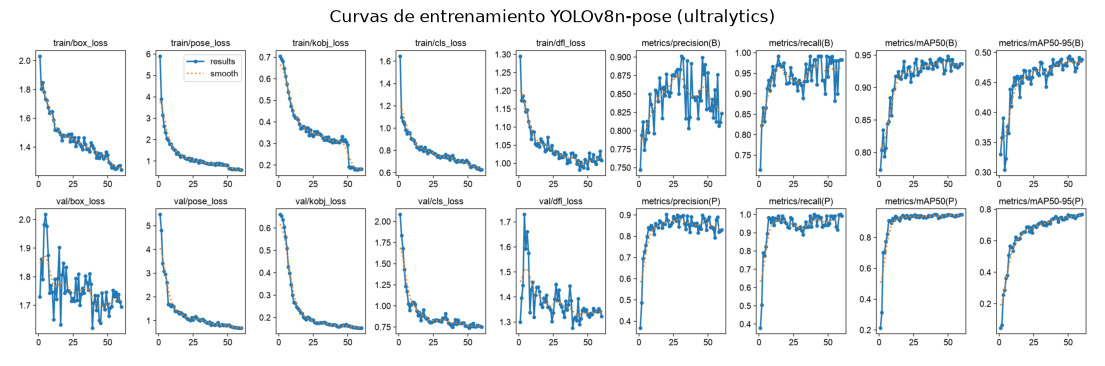

In [3]:

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

run_dir = Path(results.save_dir)
print("Resultados en:", run_dir)

results_png = run_dir / "results.png"
if results_png.exists():
    img = mpimg.imread(results_png)
    plt.figure(figsize=(14, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Curvas de entrenamiento YOLOv8n-pose (ultralytics)")
    plt.show()



## Checkpoint 3 — Validación final y ejemplos de predicción


In [4]:

metrics = model.val(data=str(yaml_path), split="test")
print(metrics.results_dict)


Ultralytics 8.4.162 🚀 Python-3.12.13 torch-2.14.0 CPU (Apple M4)
YOLOv8n-pose summary (fused): 81 layers, 3,078,128 parameters, 0 gradients, 8.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 223.7±67.5 MB/s, size: 52.1 KB)
val: Scanning /Users/psychobolt/Documents/education/universidad_de_la_sabana/maestria_en_inteligencia_artificial/asignaturas/TAIA/unidad_2/padel-impact-position-detection/data/Padel_an_2-6/test/labels... 33 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 33/33 4.6Kit/s 0.0s
val: New cache created: /Users/psychobolt/Documents/education/universidad_de_la_sabana/maestria_en_inteligencia_artificial/asignaturas/TAIA/unidad_2/padel-impact-position-detection/data/Padel_an_2-6/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 4.0it/s 0.7s0.6s
                   all         33        109      0.771      0.972      0.871       0.48      0.7

Pesos del mejor checkpoint: /Users/psychobolt/Documents/education/universidad_de_la_sabana/maestria_en_inteligencia_artificial/asignaturas/TAIA/unidad_2/padel-impact-position-detection/runs/pose/padel_yolo_pose/weights/best.pt True


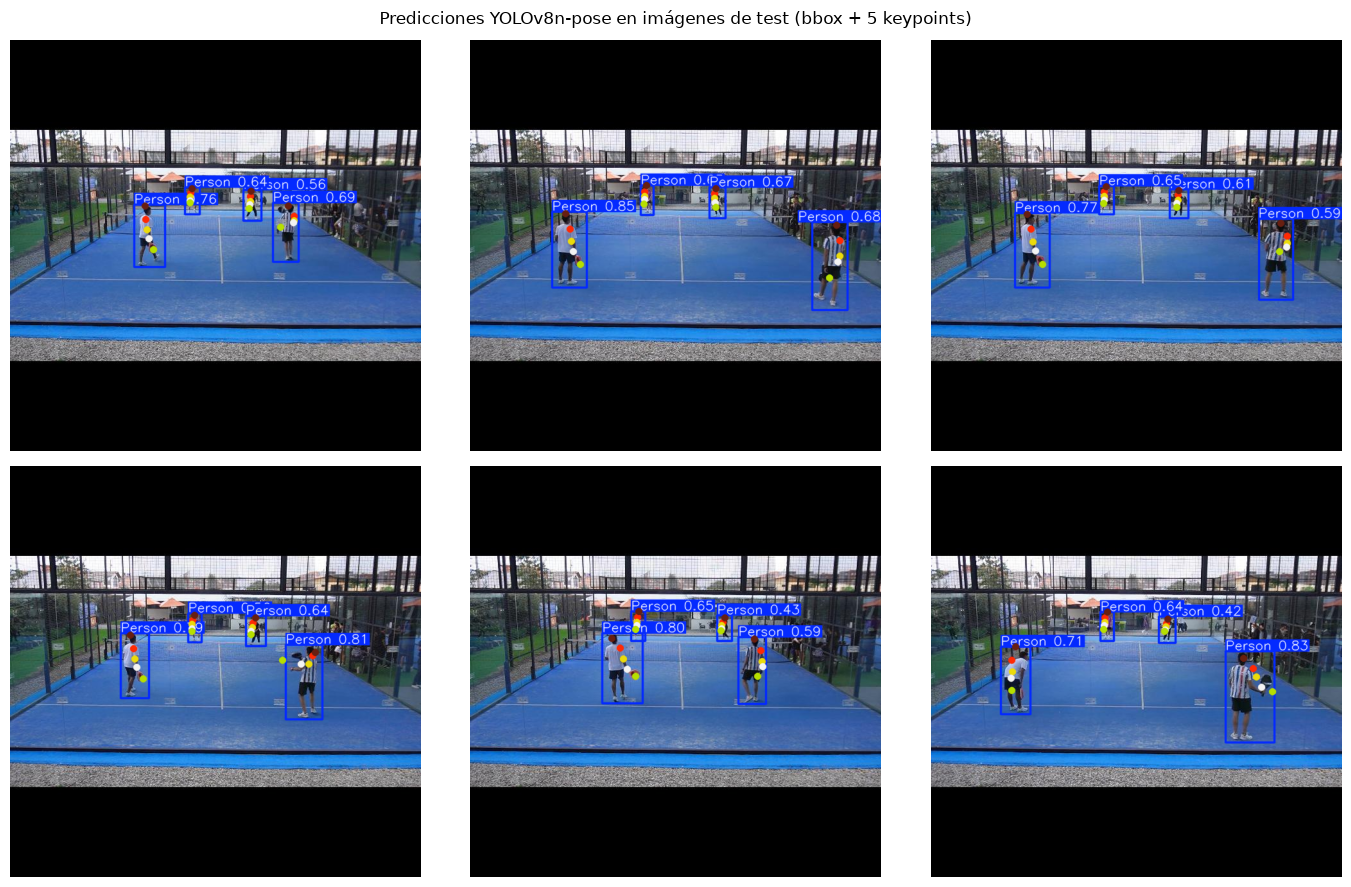

In [5]:

best_weights = run_dir / "weights" / "best.pt"
print("Pesos del mejor checkpoint:", best_weights, best_weights.exists())

pred_model = YOLO(str(best_weights))
test_images = sorted((DATA_DIR / "test" / "images").glob("*.jpg"))[:6]
preds = pred_model.predict(source=[str(p) for p in test_images], imgsz=384, conf=0.25, verbose=False)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, r in zip(axes.flat, preds):
    ax.imshow(r.plot()[:, :, ::-1])
    ax.axis("off")
plt.suptitle("Predicciones YOLOv8n-pose en imágenes de test (bbox + 5 keypoints)")
plt.tight_layout()
plt.show()



## Checkpoint 4 — Artefacto para el framework de inferencia en video

Se deja registrada la ruta de los pesos entrenados; `run_inference_video.py` la usa para procesar un
video completo con tracking de jugadores.


In [6]:

import json

artifact = {"weights_path": str(best_weights.resolve()), "imgsz": 384,
            "kpt_names": ["hombro", "codo", "muneca", "raqueta", "cabeza"]}  # orden real, ver actividad_3_clasificacion_visual_cnn.ipynb Checkpoint 0.6
with open(ROOT / "data" / "processed" / "pose_model_artifact.json", "w") as f:
    json.dump(artifact, f, indent=2)
print(artifact)


{'weights_path': '/Users/psychobolt/Documents/education/universidad_de_la_sabana/maestria_en_inteligencia_artificial/asignaturas/TAIA/unidad_2/padel-impact-position-detection/runs/pose/padel_yolo_pose/weights/best.pt', 'imgsz': 384, 'kpt_names': ['hombro', 'codo', 'muneca', 'raqueta', 'cabeza']}
